In [2]:
import pandas as pd

# Define the table data
data = {
    "Task": [
        "SVM Model using Word2Vec",
        "Training Data Check",
        "AUC plotted?",
        "Feature Engineering",
        "Cross Validation",
        "Interpretability",
        "Testing Data Check",
        "Next Steps"
    ],
    "Status": [
        "Config: CBOW, vector size=128, kernel=RBF",
        "Confusion Matrix Built?",
        "AUC = [0.56, 0.57, 0.64, 0.68, 0.66]",
        "Features Added: TF-IDF Weights, Stopword Removal",
        "5-Fold CV",
        "Implemented LIME",
        "Confusion Matrix Built?",
        "1. Use BERT for improved embeddings.\n2. Experiment with BiLSTM.\n3. Use other embeddings like FastText."
    ],
    "Results": [
        "Train Time = 381.58 seconds",
        "F1-Macro = 0.22, F1-Weighted = 0.42, F1-Micro = 0.54",
        "Accuracy = 54",
        "-",
        "Avg F1-Score = ?, Accuracy = ?",
        "2 key findings: (1) ?, (2) ?",
        "F1-Positive = ?, F1-Negative = ?",
        "-"
    ]
}

# Create the DataFrame
df = pd.DataFrame(data)

# Display the table
df.style.set_properties(**{'text-align': 'left'})


,Task,Status,Results
0,SVM Model using Word2Vec,"Config: CBOW, vector size=128, kernel=RBF",Train Time = 381.58 seconds
1,Training Data Check,Confusion Matrix Built?,"F1-Macro = 0.22, F1-Weighted = 0.42, F1-Micro = 0.54"
2,AUC plotted?,"AUC = [0.56, 0.57, 0.64, 0.68, 0.66]",Accuracy = 54
3,Feature Engineering,"Features Added: TF-IDF Weights, Stopword Removal",-
4,Cross Validation,5-Fold CV,"Avg F1-Score = ?, Accuracy = ?"
5,Interpretability,Implemented LIME,"2 key findings: (1) ?, (2) ?"
6,Testing Data Check,Confusion Matrix Built?,"F1-Positive = ?, F1-Negative = ?"
7,Next Steps,1. Use BERT for improved embeddings. 2. Experiment with BiLSTM. 3. Use other embeddings like FastText.,-


In [3]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.utils import resample
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
# Download necessary NLTK datasets
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

 


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\anjit\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\anjit\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\anjit\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## Load and sample data 

In [4]:
# Load the dataset
df = pd.read_csv("Sentiment_Data.csv", encoding="ISO-8859-1")

print("Original DF indices:", df.index.min(), "to", df.index.max())  # Before sampling
sample_df = df.sample(n=25000, random_state=42).reset_index(drop=True)
print("Sample DF indices:", sample_df.index.min(), "to", sample_df.index.max()) 


Original DF indices: 0 to 451331
Sample DF indices: 0 to 24999


In [5]:

# OR use a fixed number of rows (e.g., 25000)
sample_df = df.sample(n=25000, random_state=42)

# Display the shape of the sample
print(sample_df.shape)



(25000, 2)


In [6]:
# Drop duplicates and rows with missing tweets
sample_df.drop_duplicates(inplace=True)
sample_df.dropna(subset=["Tweet"], inplace=True)

# Convert text to lowercase
sample_df["Tweet"] = sample_df["Tweet"].str.lower()

# Precompute stopwords once, outside the function
stop_words_set = set(stopwords.words("english"))

# Lemmatizer
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Remove URLs, mentions, hashtags
    text = re.sub(r"http\S+|www\S+|@\S+|#\S+", "", text)
    # Remove punctuation & special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    # Tokenize and remove stopwords, apply lemmatization
    words = word_tokenize(text)
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words_set]
    return " ".join(words)

# Apply text cleaning
sample_df["Tweet"] = sample_df["Tweet"].apply(clean_text)

In [7]:
df = df.dropna(subset=['Tweet'])  # Drop rows where 'Tweet' column is NaN
df.loc[:, 'Tweet'] = df['Tweet'].fillna('')  # Replace NaN with an empty string
# Check for NaN values in the 'Tweet' column
print(df['Tweet'].isna().sum())  # This will show the count of NaN values in the 'Tweet' column


0


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from nltk.tokenize import word_tokenize
import numpy as np

# Apply TF-IDF to the 'Tweet' column
tfidf_vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(df["Tweet"])  # Use `df` instead of `sample_df` for consistency

print("TF-IDF Features Added! Shape:", X_tfidf.shape)

# ✅ Use `tfidf_vectorizer` instead of `vectorizer`
X_sample_tfidf = tfidf_vectorizer.fit_transform(sample_df['Tweet'])

# Ensure that 'y' is from the same sampled dataframe
y_sample = sample_df['Sentiment']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_sample_tfidf, y_sample, test_size=0.3, random_state=42)

# Get original indices before splitting
train_indices, test_indices = train_test_split(
    np.arange(sample_df.shape[0]), test_size=0.2, random_state=42
)

# Tokenize using the original indices
X_train_tokens = sample_df["Tweet"].iloc[train_indices].apply(word_tokenize)
X_test_tokens = sample_df["Tweet"].iloc[test_indices].apply(word_tokenize)

print("✅ TF-IDF and tokenization completed successfully!")


TF-IDF Features Added! Shape: (451331, 5000)
✅ TF-IDF and tokenization completed successfully!


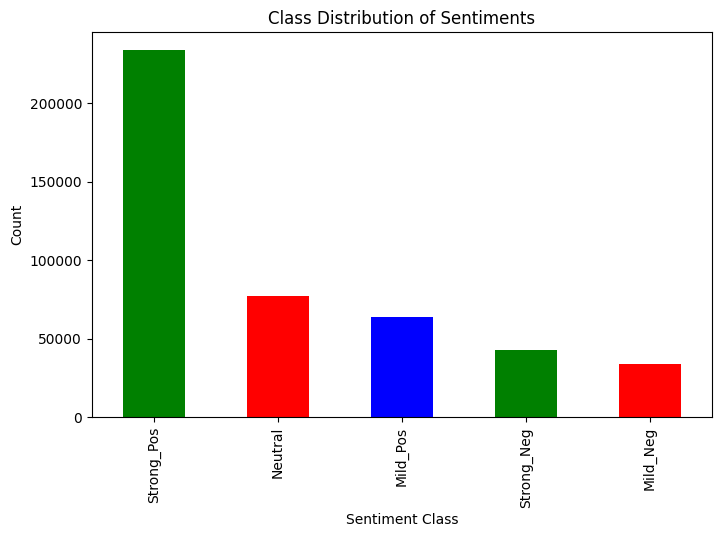

Class Distribution Before Balancing:
Sentiment
Strong_Pos    12906
Neutral        4236
Mild_Pos       3559
Strong_Neg     2393
Mild_Neg       1906
Name: count, dtype: int64


In [9]:
# Check class distribution
plt.figure(figsize=(8, 5))
df["Sentiment"].value_counts().plot(kind="bar", color=["green", "red", "blue"])
plt.xlabel("Sentiment Class")
plt.ylabel("Count")
plt.title("Class Distribution of Sentiments")
plt.show()

# Print class distribution
class_counts = sample_df["Sentiment"].value_counts()
print("Class Distribution Before Balancing:")
print(class_counts)

# Define the majority and minority classes
max_class = class_counts.idxmax()  # Majority class
min_class = class_counts.idxmin()  # Minority class

# Apply undersampling for the majority class
df_majority = sample_df[sample_df["Sentiment"] == max_class]
df_minority = sample_df[sample_df["Sentiment"] != max_class]

In [10]:
from imblearn.over_sampling import SMOTE

# Original class distribution
class_counts = {'Mild_Neg': 1367, 'Mild_Pos': 2521, 'Neutral': 2965, 'Strong_Neg': 1654, 'Strong_Pos': 8993}

# Define valid sampling strategy (must be >= original values)
sampling_strategy = {
    'Mild_Neg': 2000,  # Should be >= 1367
    'Mild_Pos': 3000,  # Should be >= 2521
    'Neutral': 3500,   # Should be >= 2965
    'Strong_Neg': 2000,  # Should be >= 1654
    'Strong_Pos': 8993   # Keep unchanged (or increase)
}

# Apply SMOTE correctly
smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print(f"Resampled shape: {X_resampled.shape}, {y_resampled.shape}")


C:\Users\anjit\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Resampled shape: (19493, 5000), (19493,)


## Word2Vec Model Training 

In [11]:
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
import numpy as np

# Tokenize training and test data
X_train_tokens = sample_df.loc[y_train.index, "Tweet"].apply(word_tokenize)
X_test_tokens = sample_df.loc[y_test.index, "Tweet"].apply(word_tokenize)

# Train and save Word2Vec model
word2vec_model = Word2Vec(sentences=X_train_tokens, vector_size=128, window=5, min_count=1, sg=0)
word2vec_model.save("word2vec.model")


## Convert Text Data to Word2Vec Embeddings

In [12]:
# Load trained Word2Vec model
word2vec_model = Word2Vec.load("word2vec.model")

# Function to get the average word vector for each tweet
def get_avg_vector(tokens, model):
    vectors = [model.wv[token] for token in tokens if token in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

# Convert Tweets to Word2Vec Vectors
X_train_w2v = np.array([get_avg_vector(tokens, word2vec_model) for tokens in X_train_tokens])
X_test_w2v = np.array([get_avg_vector(tokens, word2vec_model) for tokens in X_test_tokens])


## Train SVM Model

In [13]:
# 1. Training Block

import time
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA

# Record start time
start_time = time.time()

# Create PCA instance and fit it on the training data
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_w2v)

# Define pipeline with standard scaling and SVM classifier
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(probability=True))
])

# Train the model
pipeline.fit(X_train_pca, y_train)

# Record end time and print training time
train_time = time.time() - start_time
print(f"Train Time = {train_time:.2f} seconds")

# Save the trained model
import joblib
joblib.dump(pipeline, "svm_model.pkl")


Train Time = 505.52 seconds


['svm_model.pkl']

## Model Evaluation

Confusion Matrix:
 [[  1   0   3   0  64]
 [  0   2   4   0 136]
 [  0   0  38   0 133]
 [  1   0   5   0 106]
 [  0   3   6   0 498]]
F1 Score for Positive = 0.03
F1 Score for Negative = 0.03
AUC for class 0: 0.54
AUC for class 1: 0.58
AUC for class 2: 0.64
AUC for class 3: 0.69
AUC for class 4: 0.65
Accuracy = 0.54


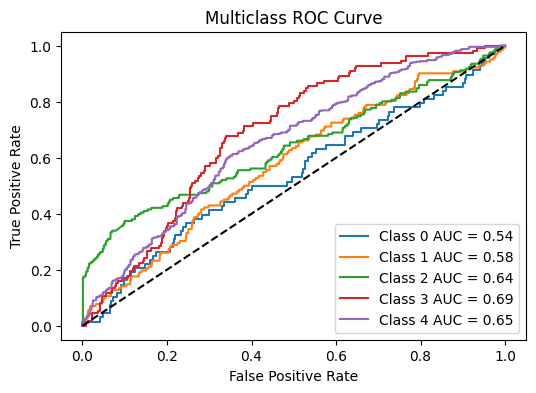

In [14]:
from sklearn.metrics import confusion_matrix, f1_score, roc_curve, auc, roc_auc_score, accuracy_score
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt
from joblib import load

# Load the trained model
pipeline = load("svm_model.pkl")

# Apply PCA transformation to test data separately
X_test_pca = pca.transform(X_test_w2v[:1000])

# Binarize y_test for multiclass ROC curve
y_test_sample = y_test[:1000]
y_test_bin = label_binarize(y_test_sample, classes=np.unique(y_test))

# Compute predictions
y_test_pred = pipeline.predict(X_test_pca)

# Compute Confusion Matrix
conf_matrix = confusion_matrix(y_test_sample, y_test_pred)
print("Confusion Matrix:\n", conf_matrix)

# Compute F1-Scores (Macro, Weighted, Micro)
f1_per_class = f1_score(y_test_sample, y_test_pred, average=None)

# Extract F1 Scores for Positive and Negative Classes
f1_positive = f1_per_class[1] if len(f1_per_class) > 1 else "N/A"
f1_negative = f1_per_class[0] if len(f1_per_class) > 0 else "N/A"

print(f"F1 Score for Positive = {f1_positive:.2f}")
print(f"F1 Score for Negative = {f1_negative:.2f}")

# Compute AUC for each class
y_test_proba = pipeline.predict_proba(X_test_pca)
aucs = []
for i in range(len(np.unique(y_test_sample))):
    auc_class = roc_auc_score(y_test_bin[:, i], y_test_proba[:, i])
    aucs.append(auc_class)
    print(f"AUC for class {i}: {auc_class:.2f}")

# Compute Accuracy
accuracy = accuracy_score(y_test_sample, y_test_pred)
print(f"Accuracy = {accuracy:.2f}")

# Plot ROC Curve for Each Class
plt.figure(figsize=(6, 4))
for i, auc_class in enumerate(aucs):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    plt.plot(fpr, tpr, label=f'Class {i} AUC = {auc_class:.2f}')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal reference line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.legend(loc="lower right")
plt.show()


## Lime implementation

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Rebuild the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),  
    ('classifier', SVC(kernel='linear', probability=True))  # Use a linear kernel
])

# Fit pipeline on X_train_w2v (128 features)
pipeline.fit(X_train_w2v, y_train)  

# Transform X_train_w2v
X_train_scaled = pipeline.named_steps["scaler"].transform(X_train_w2v)

# Print to verify
print("Updated SVC features:", pipeline.named_steps["classifier"].n_features_in_)  # Should be 128
print("Transformed X_train_scaled shape:", X_train_scaled.shape)  # Should be (17500, 128)

# Now use LIME
explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_w2v,  # Use unscaled data
    training_labels=y_train,  
    mode='classification',
    feature_selection='auto',  # Automatically selects important features
    num_samples=1000  # Reduce number of perturbed samples
)


# Get a test instance
instance_idx = 0  
instance = pipeline.named_steps["scaler"].transform(X_test_w2v[instance_idx].reshape(1, -1))

# Explain prediction
exp = explainer.explain_instance(instance[0], pipeline.predict_proba)

# Show explanation
exp.show_in_notebook()


## Evaluation

In [ ]:
from sklearn.metrics import confusion_matrix, f1_score
import numpy as np
# Make predictions on the test data
y_test_pred = pipeline.predict(X_test_pca)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test[:1000], y_test_pred)
print("Confusion Matrix:\n", conf_matrix)

# Compute F1-scores for positive and negative classes (assuming binary classification)
f1_positive = f1_score(y_test[:1000], y_test_pred, average='binary', pos_label
                       =1)
f1_negative = f1_score(y_test[:1000], y_test_pred, average='binary', pos_label=0)

print(f"F1-Positive = {f1_positive:.2f}")
print(f"F1-Negative = {f1_negative:.2f}")
